### Übung 5

#### Aufgabe 1 (10)

Verwenden Sie den Genexpressionsdatensatz aus Übung 4 (gefiltert nach regulierten Genen & skaliert, aber __nicht__ PCA-transformiert) und versuchen Sie die Daten mit dem k-means Clusteralgorithmus zu Clustern. 

__a)__ Initialisieren Sie dabei die Cluster zufällig und lassen Sie den Algorithmus für alle k $\in$ [2,10] je 5 mal laufen. Visualisieren Sie die Inertia (WSS) mit einem Elbowplot, zeichnen Sie hier auch die Standardabweichung ein. Warum macht es Sinn, nicht einfach nur den Mittelwert der Inertia je k zu zeigen? (Hinweis: Initialisieren Sie die Cluster zufällig und verwenden Sie für diese Aufgabe kmeans++ maximal als Zusatz) 

,k,mean,std
0,1,4840.000000,0.000000
1,2,3264.969458,26.329043
2,3,2939.060273,167.854268
3,4,2765.036091,178.125916
4,5,2491.177492,146.125526
5,6,2140.469727,185.599665
6,7,2016.326496,157.669707
7,8,1794.152231,231.579062
8,9,1695.942936,222.880686
9,10,1534.756388,275.630297


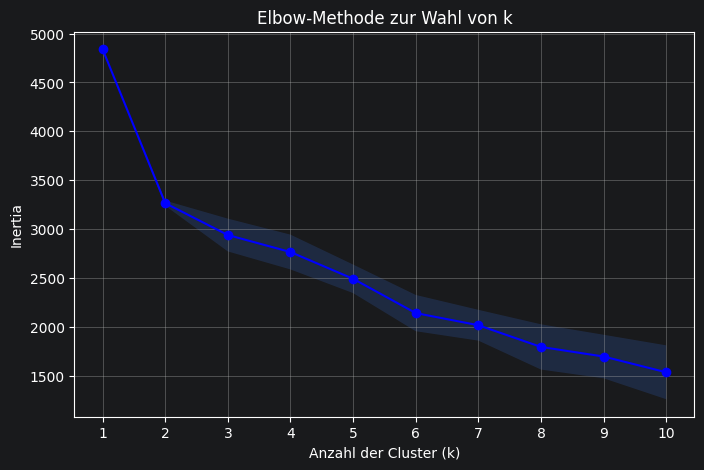

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

metadata = pd.read_csv("metadata.txt", sep=r"\s+", header=None, names=["Sample", "Smoker"])
gse = pd.read_csv("GSE4498_series_data.txt", sep="\t")
regulated = pd.read_csv("regulatedGenes.txt", header=None, names=["ProbeID"])

gse_filtered = gse[gse["ID_REF"].isin(regulated["ProbeID"])]
X = gse_filtered.set_index("ID_REF").T
X = X.loc[metadata["Sample"]]
X_scaled = StandardScaler().fit_transform(X)

inertia_results = []
k_values = range(1, 11)

for k in k_values:
    for run in range(5):
        k_means = KMeans(n_clusters=k, init="random", n_init=1, random_state=run)
        k_means.fit(X_scaled)
        inertia_results.append([k, run + 1, k_means.inertia_])

inertia_df = pd.DataFrame(inertia_results, columns=["k", "run", "inertia"])
inertia_summary = inertia_df.groupby("k")["inertia"].agg(["mean", "std"]).reset_index()

display(inertia_summary)

plt.figure(figsize=(8, 5))
plt.plot(inertia_summary["k"], inertia_summary["mean"], "bo-", markersize=6)
plt.fill_between(inertia_summary["k"], inertia_summary["mean"] - inertia_summary["std"], inertia_summary["mean"] + inertia_summary["std"], alpha=0.2)
plt.xlabel("Anzahl der Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow-Methode zur Wahl von k")
plt.grid(True)
plt.xticks(k_values)
plt.show()

# Die Standardabweichung ist wichtig, weil k-means bei zufaelliger Initialisierung unterschiedliche lokale Optimums finden kann. Nur der Mittelwert würde keine aussage darüber treffen ob das K stabiel Klustert oder je nach startpunkt sehr unterschiedlich klustert.

__b)__ Lassen Sie sich die Silhouette-Scores anzeigen (gemittelt für jedes k mit Standardabweichung).

For n_clusters = 2, Silhouette Score = 0.274, SD = 0.107


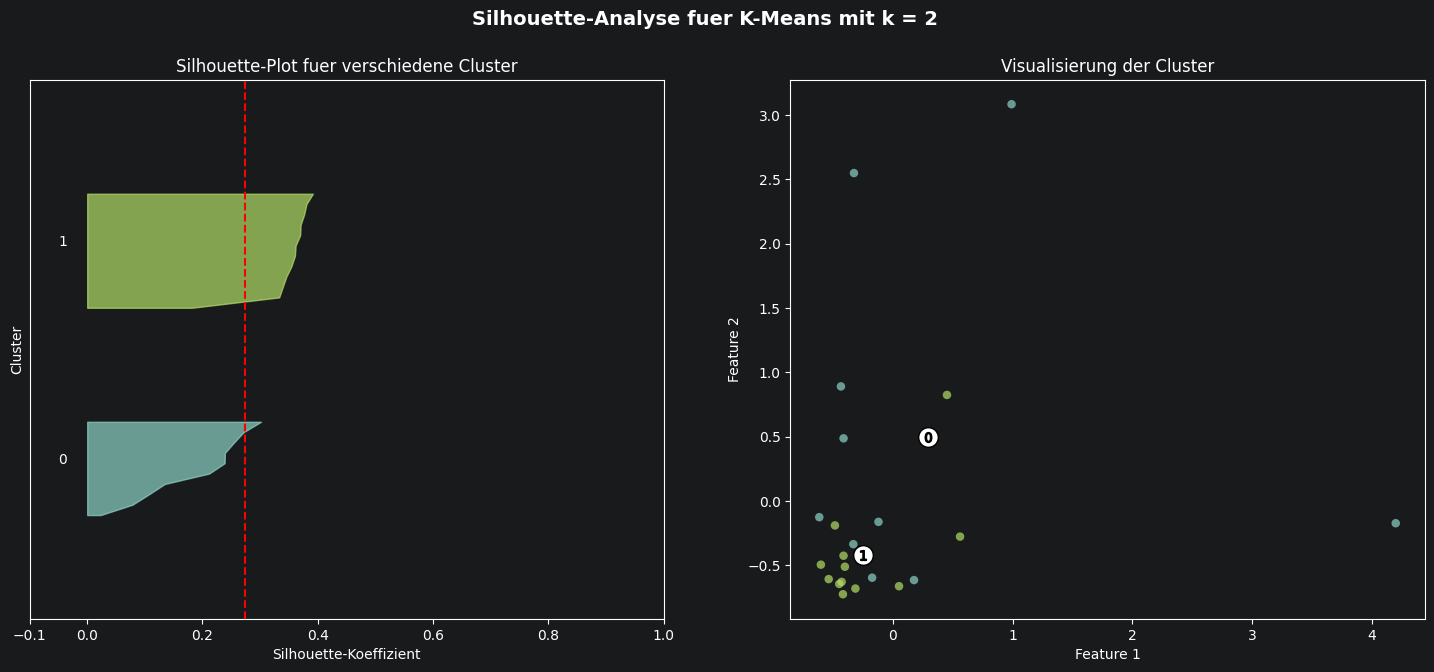

For n_clusters = 3, Silhouette Score = 0.247, SD = 0.126


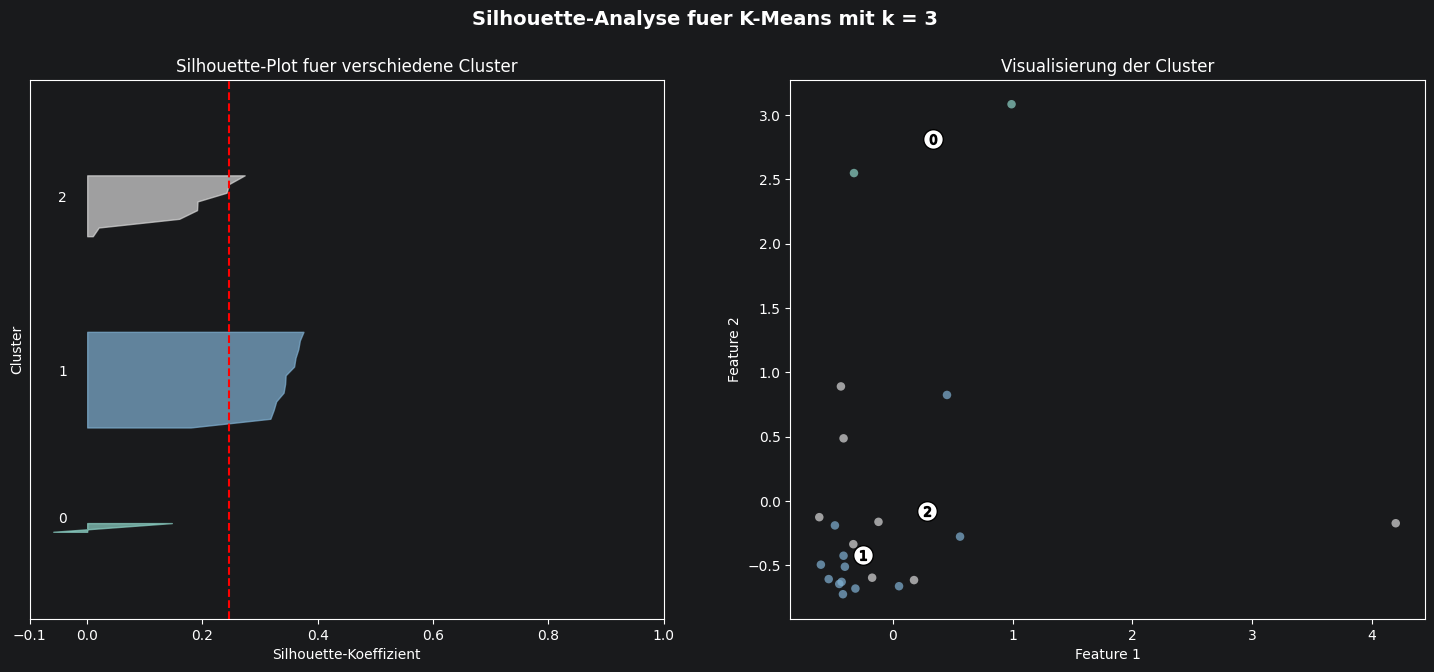

For n_clusters = 4, Silhouette Score = 0.082, SD = 0.107


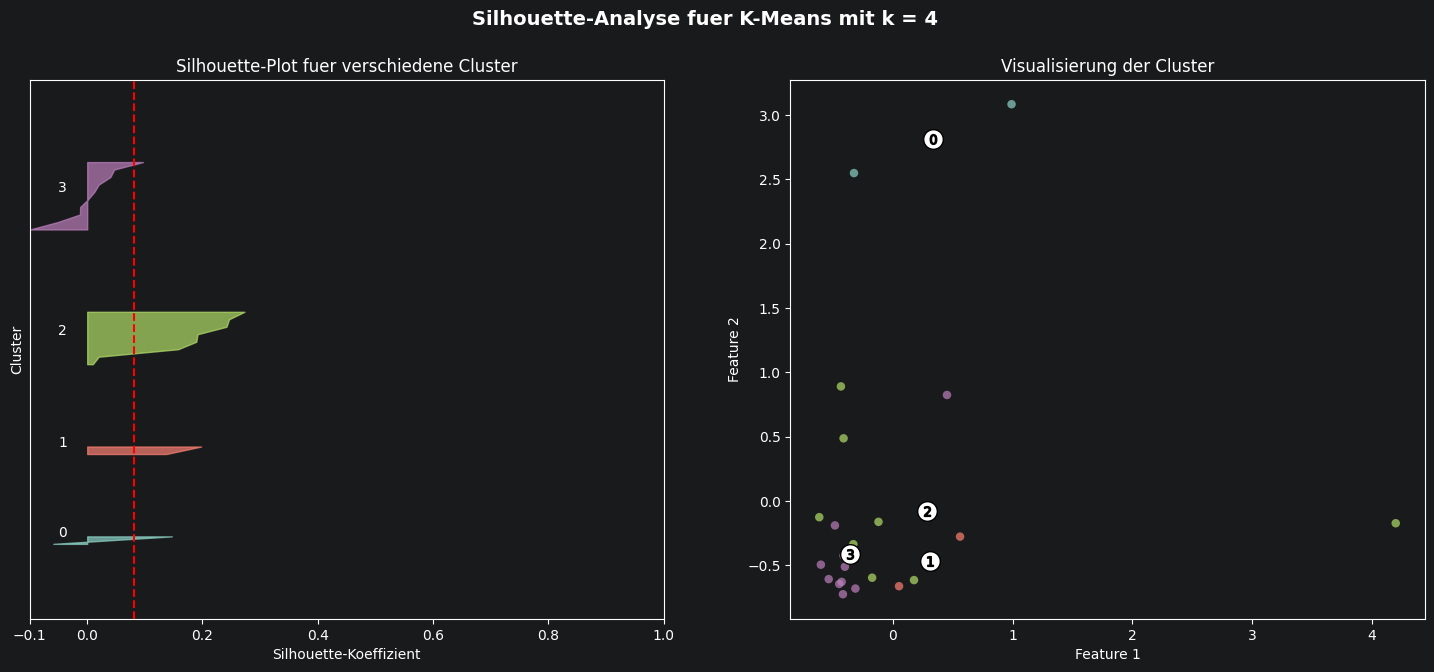

For n_clusters = 5, Silhouette Score = 0.013, SD = 0.090


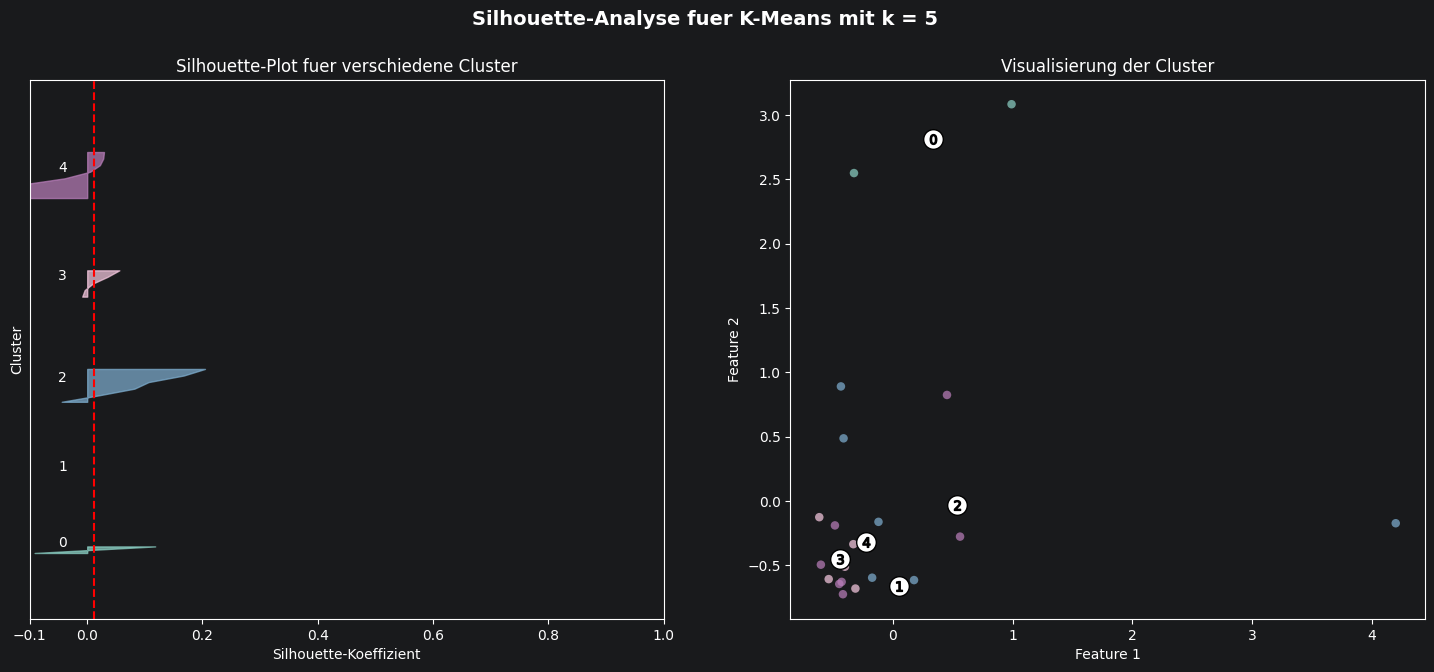

For n_clusters = 6, Silhouette Score = 0.052, SD = 0.087


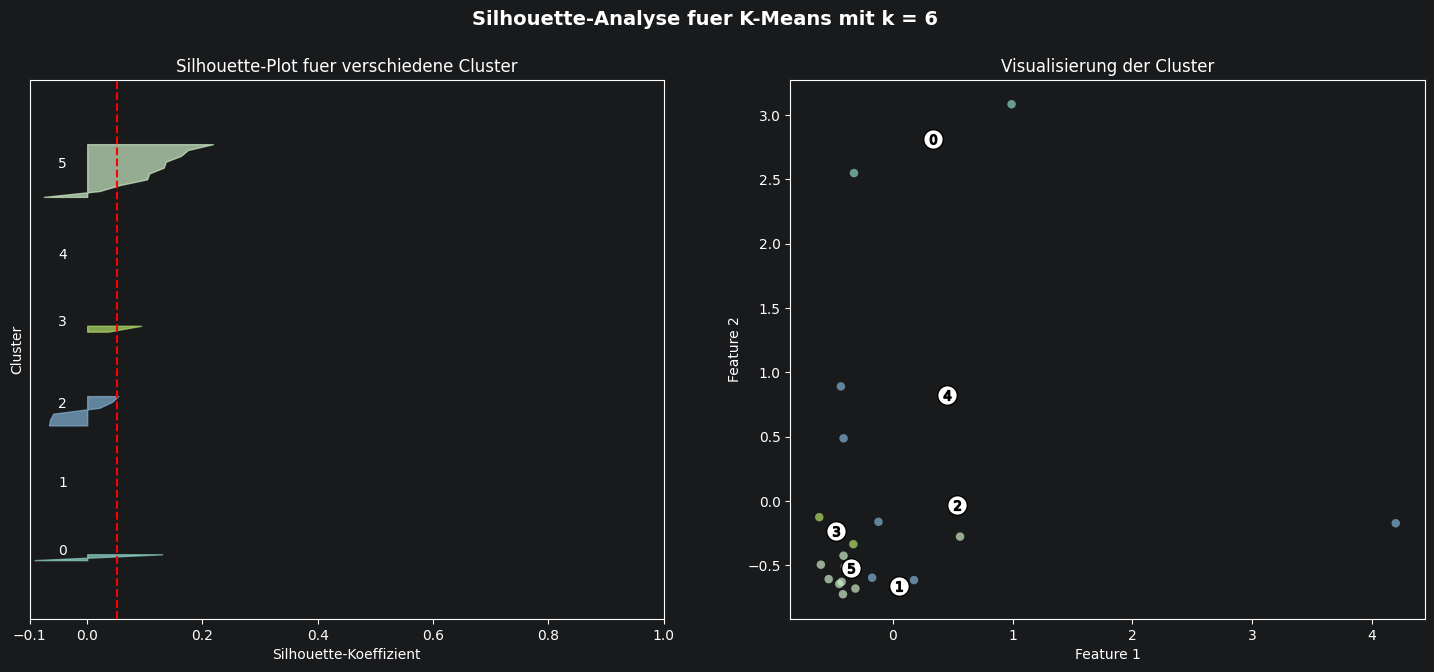

For n_clusters = 7, Silhouette Score = 0.103, SD = 0.085


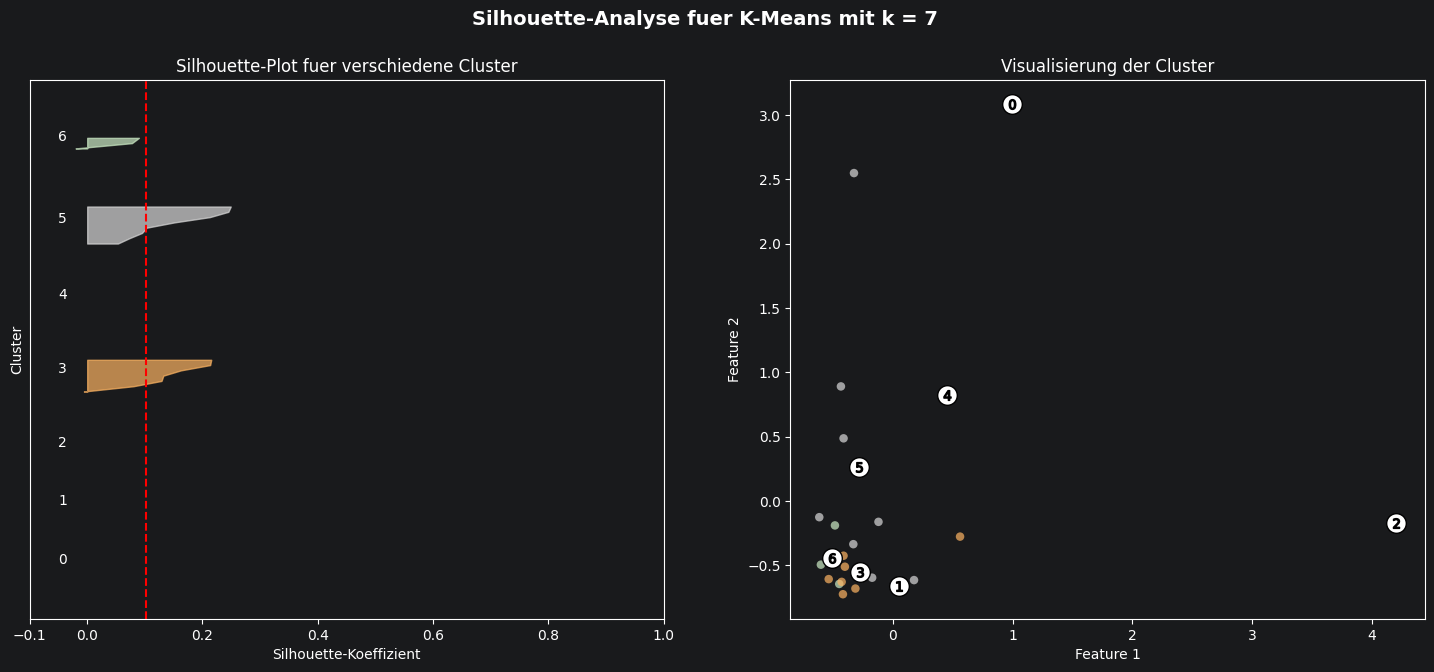

For n_clusters = 8, Silhouette Score = 0.011, SD = 0.112


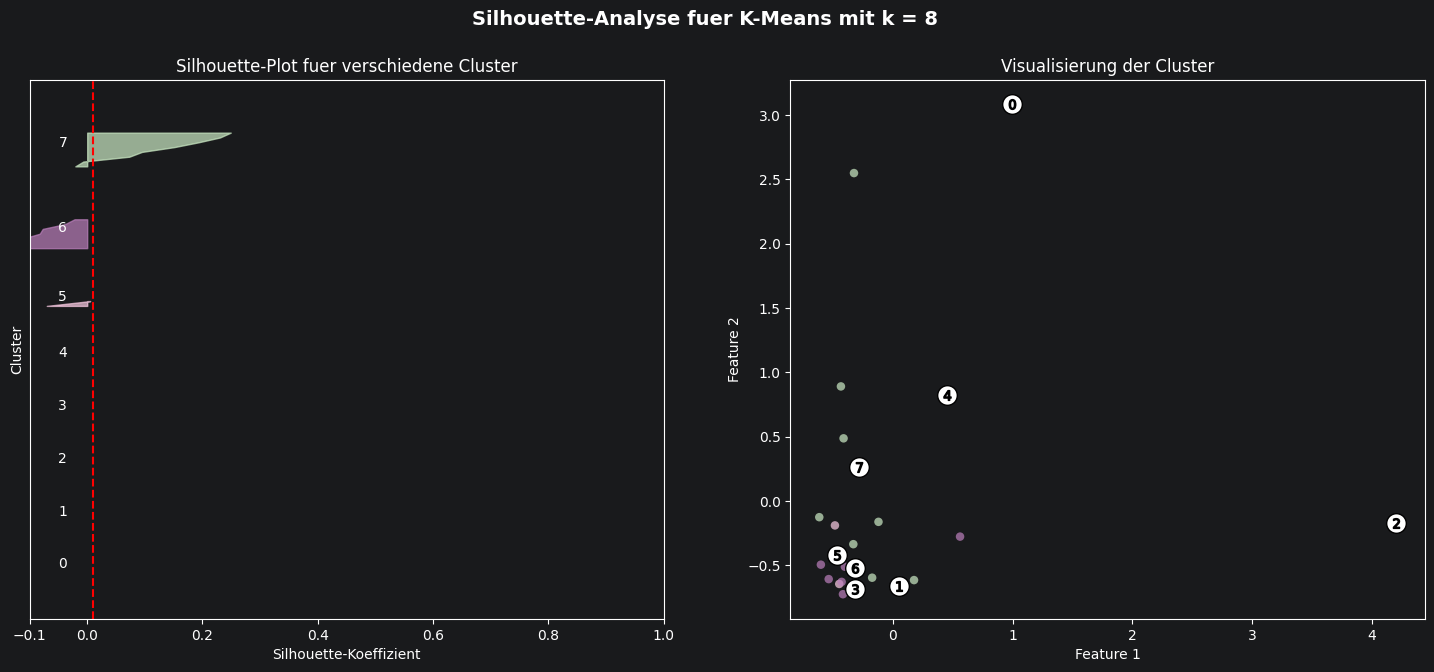

For n_clusters = 9, Silhouette Score = -0.035, SD = 0.068


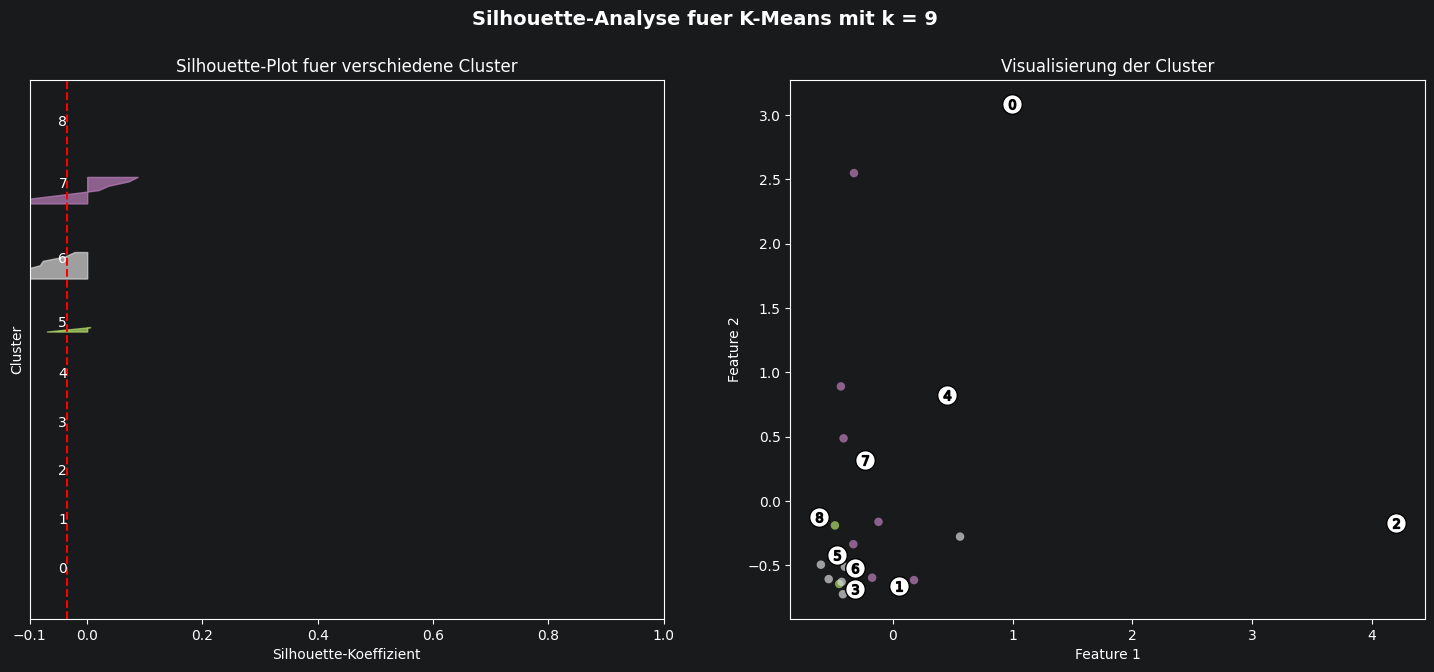

For n_clusters = 10, Silhouette Score = -0.031, SD = 0.066


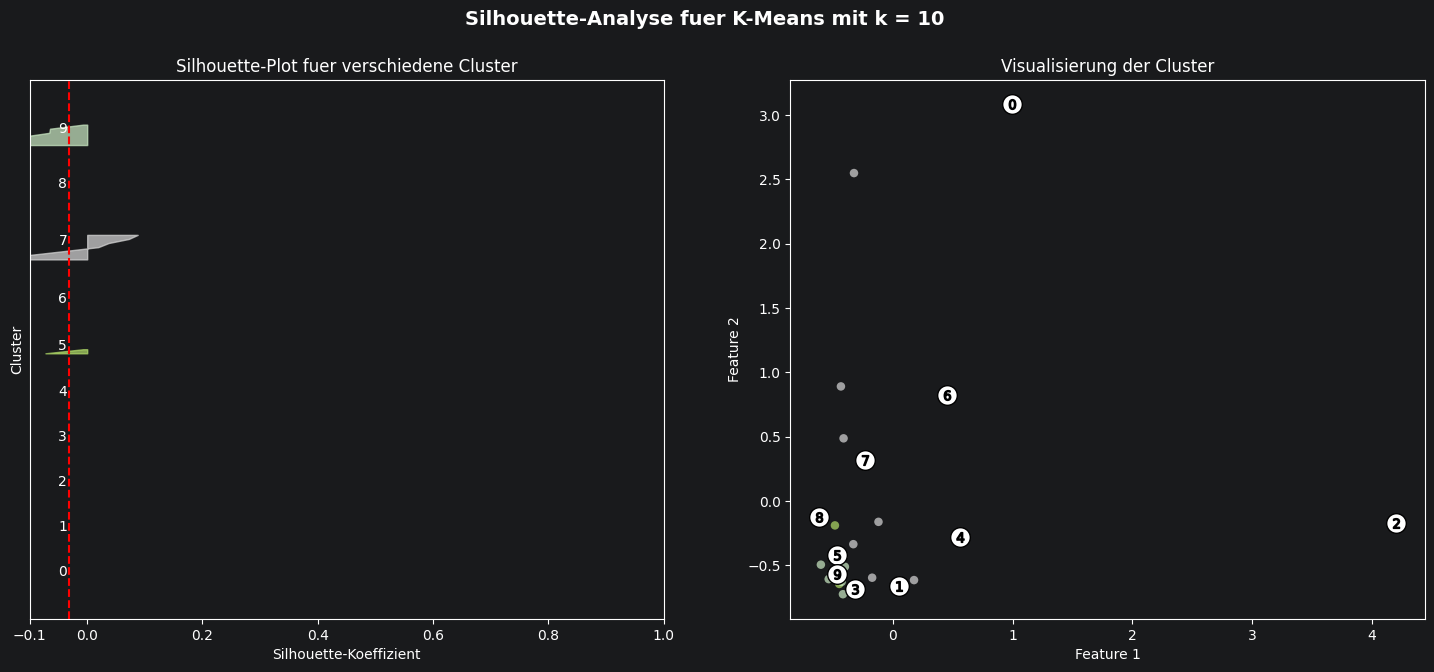

,k,mean,std
0,2,0.273713,0.107200
1,3,0.246666,0.125515
2,4,0.081556,0.107466
3,5,0.012551,0.090200
4,6,0.051585,0.086930
5,7,0.102533,0.085227
6,8,0.010918,0.111859
7,9,-0.035481,0.068487
8,10,-0.031396,0.066304


In [21]:
import matplotlib.cm as cm
silhouette_means = []
silhouette_stds = []
X = X_scaled

range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, init="random", n_init=1, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_means.append(silhouette_avg)

    silhouette_std = np.std(sample_silhouette_values)
    silhouette_stds.append(silhouette_std)

    print(f"For n_clusters = {n_clusters}, Silhouette Score = {silhouette_avg:.3f}, SD = {silhouette_std:.3f}")

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.Set3(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    ax1.set_title("Silhouette-Plot für verschiedene Cluster")
    ax1.set_xlabel("Silhouette-Koeffizient")
    ax1.set_ylabel("Cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.Set3(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker=".", s=150, lw=0, alpha=0.7, c=colors, edgecolor="k")

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("Visualisierung der Cluster")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")

    plt.suptitle("Silhouette-Analyse fuer K-Means mit k = %d" % n_clusters, fontsize=14, fontweight="bold")
    plt.show()

silhouette_summary = pd.DataFrame({
    "k": list(range_n_clusters),
    "mean": silhouette_means,
    "std": silhouette_stds
})

display(silhouette_summary)

__c)__ Diskutieren Sie Ihre Ergebnisse - was ist das richtige k? Kann die Inertia gleich 0 sein? Falls ja, wann?

In [27]:
best_k = silhouette_summary.loc[silhouette_summary["mean"].idxmax(), "k"]
print("Bestes k nach mittlerem Silhouette-Score:", best_k)

display(inertia_summary)
display(silhouette_summary)

# Sinnvoll ist hier k=2, weil der Silhouette-Score dort am besten ist und der Elbowplot danach deutlich flacher wird. Das passt auch zur Einteilung in Raucher und Nicht-Raucher.
# Die Inertia kann 0 sein, wenn jedes unterschiedliche Objekt ein eigenes Clusterzentrum bekommt, also bei k groesser/gleich der Anzahl unterschiedlicher Datenpunkte.

Bestes k nach mittlerem Silhouette-Score: 2


,k,mean,std
0,1,4840.000000,0.000000
1,2,3264.969458,26.329043
2,3,2939.060273,167.854268
3,4,2765.036091,178.125916
4,5,2491.177492,146.125526
5,6,2140.469727,185.599665
6,7,2016.326496,157.669707
7,8,1794.152231,231.579062
8,9,1695.942936,222.880686
9,10,1534.756388,275.630297


,k,mean,std
0,2,0.273713,0.107200
1,3,0.246666,0.125515
2,4,0.081556,0.107466
3,5,0.012551,0.090200
4,6,0.051585,0.086930
5,7,0.102533,0.085227
6,8,0.010918,0.111859
7,9,-0.035481,0.068487
8,10,-0.031396,0.066304


__d)__ Visualisieren Sie die Cluster für k=2 in der PCA-Darstellung. Stellen Sie dabei auch die Centroide dar. Sie erhalten Sie durch `centers=k_means.cluster_centers_`

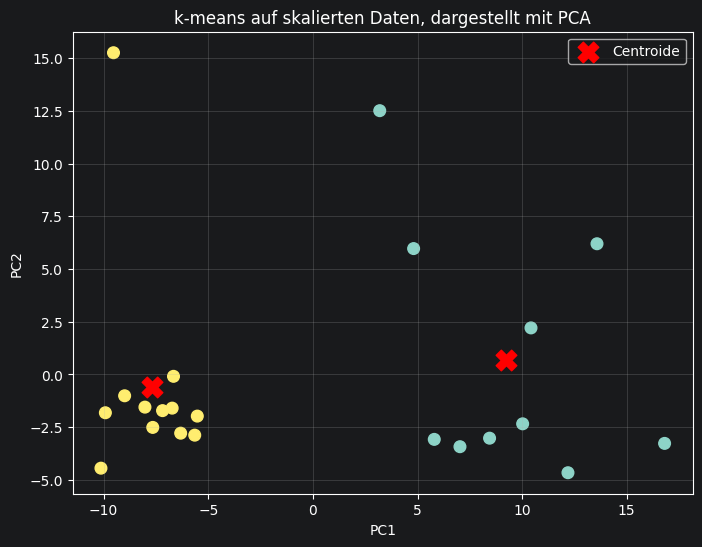

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

k_means = KMeans(n_clusters=2, init="random", n_init=5, random_state=0)
cluster_2 = k_means.fit_predict(X_scaled)
centers = pca.transform(k_means.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_2, cmap="Set3", s=70)
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=220, label="Centroide")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("k-means auf skalierten Daten, dargestellt mit PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

__e)__ Erstellen Sie k=2 Cluster für die PCA-Daten und Visualisieren Sie die Ergebnisse. Vergleichen Sie die Ergebnisse mit denen vorherigen.

PCA-Daten,0,1
volle Daten,,
0,10,0
1,0,12


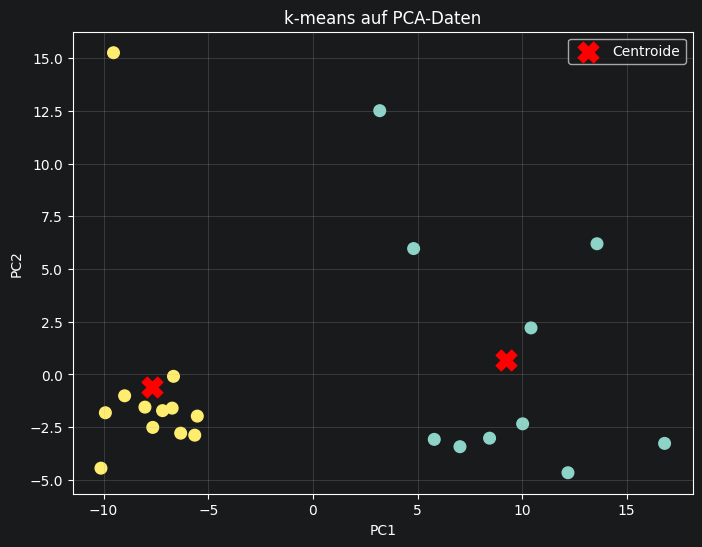

In [37]:
k_means_pca = KMeans(n_clusters=2, init="random", n_init=1)
cluster_pca = k_means_pca.fit_predict(X_pca)

display(pd.crosstab(cluster_2, cluster_pca, rownames=["volle Daten"], colnames=["PCA-Daten"]))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_pca, cmap="Set3", s=70)
plt.scatter(k_means_pca.cluster_centers_[:, 0], k_means_pca.cluster_centers_[:, 1], c="red", marker="X", s=220, label="Centroide")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("k-means auf PCA-Daten")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Beim Clustering auf den PCA-Daten werden nur PC1 und PC2 benutzt. Dadurch können die Ergebnisse von den Clustern auf den vollständig skalierten Daten abweichen, weil Information aus den übrigen Dimensionen verloren geht.

#### Aufgabe 2: k-Medoids (5)

Verwenden Sie den Iris-Datensatz.

__a)__ Visualisieren Sie die Daten mittels PCA, farblich nach Gattung markiert.

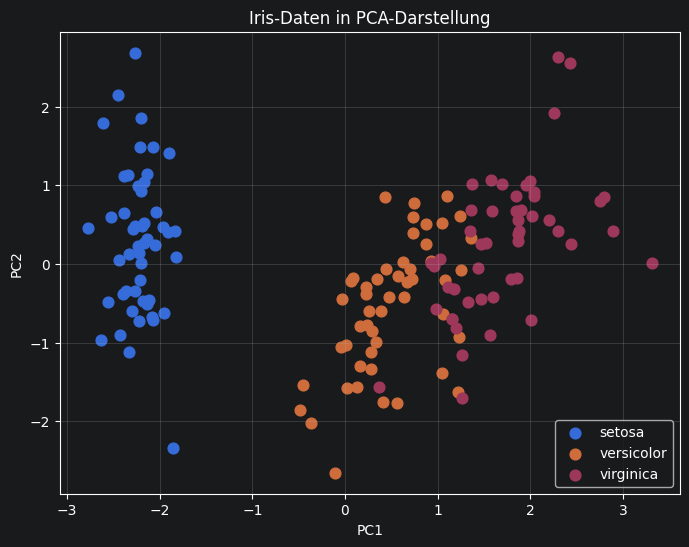

In [38]:
iris = load_iris()
iris_X = iris.data
iris_y = iris.target
iris_scaled = StandardScaler().fit_transform(iris_X)
iris_pca = PCA(n_components=2).fit_transform(iris_scaled)

plt.figure(figsize=(8, 6))
for i, name in enumerate(iris.target_names):
    mask = iris_y == i
    plt.scatter(iris_pca[mask, 0], iris_pca[mask, 1], label=name, s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris-Daten in PCA-Darstellung")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

__b)__ Clustern Sie die skalierten Daten mit dem k-Means Algorithmus. Visualisieren Sie die Ergebnisse mittels PCA (Form Spezies, Farbe Cluster). 

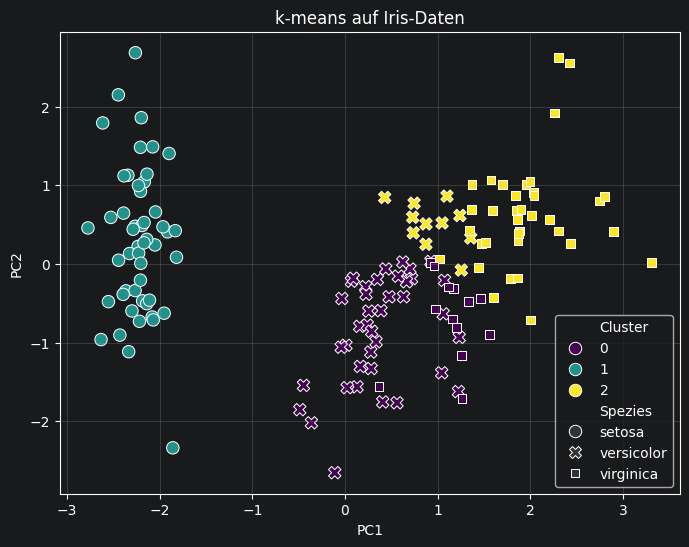

In [41]:
import seaborn as sns
iris_kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
iris_kmeans_labels = iris_kmeans.fit_predict(iris_scaled)

iris_plot = pd.DataFrame(iris_pca, columns=["PC1", "PC2"])
iris_plot["Cluster"] = iris_kmeans_labels
iris_plot["Spezies"] = iris.target_names[iris_y]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_plot, x="PC1", y="PC2", hue="Cluster", style="Spezies", palette="viridis", s=80)
plt.title("k-means auf Iris-Daten")
plt.grid(alpha=0.3)
plt.show()

__c)__ Verwenden Sie nun den k-medoids Algorithmus. Clustern und Visualisieren Sie die Daten erneut.

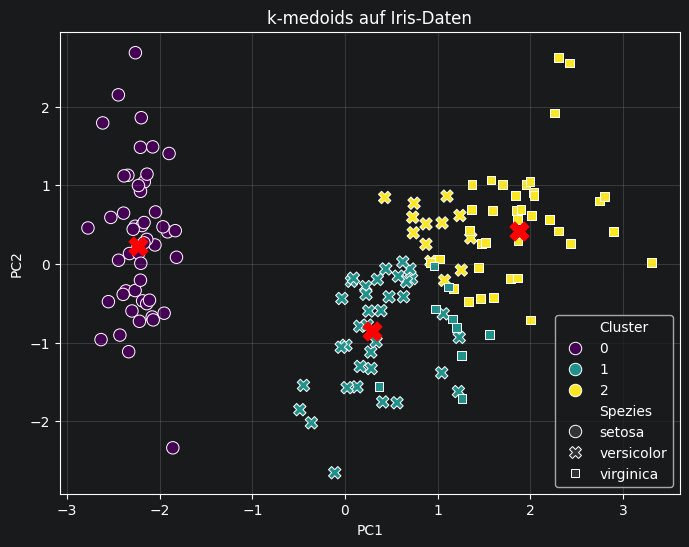

In [44]:
from pyclustering.cluster.kmedoids import kmedoids

initial_medoids = [0, 50, 100]

iris_kmedoids = kmedoids(iris_scaled.tolist(), initial_medoids)
iris_kmedoids.process()

iris_medoids_clusters = iris_kmedoids.get_clusters()
iris_medoids = iris_kmedoids.get_medoids()

iris_medoids_labels = np.zeros(len(iris_scaled), dtype=int)
for cluster_id, cluster_points in enumerate(iris_medoids_clusters):
    iris_medoids_labels[cluster_points] = cluster_id

iris_plot = pd.DataFrame(iris_pca, columns=["PC1", "PC2"])
iris_plot["Cluster"] = iris_medoids_labels
iris_plot["Spezies"] = iris.target_names[iris_y]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_plot, x="PC1", y="PC2", hue="Cluster", style="Spezies", palette="viridis", s=80)
plt.scatter(iris_pca[iris_medoids, 0], iris_pca[iris_medoids, 1], c="red", marker="X", s=180, label="Medoids")
plt.title("k-medoids auf Iris-Daten")
plt.grid(alpha=0.3)
plt.show()